In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [3]:
print("TensorFlow Version:", tf.__version__)
print("Available GPU:")
print(tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.21.0
Available GPU:
[]


In [4]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 226s 1us/step
Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


In [5]:
print(X_train[0].shape)

(32, 32, 3)


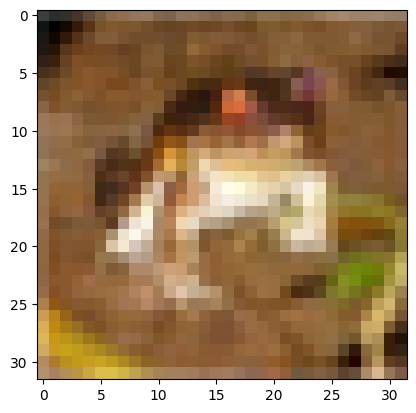

In [6]:
plt.imshow(X_train[0])
plt.show()

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Normalization Done")

Normalization Done


In [8]:
model = Sequential()

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32,32,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))

d:\6thsemesterstudy\DL theory\DL_Labs\week9-CNN-CIFAR10\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.4933 - loss: 1.4114 - val_accuracy: 0.6007 - val_loss: 1.1509
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6337 - loss: 1.0503 - val_accuracy: 0.6550 - val_loss: 0.9987
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6827 - loss: 0.9079 - val_accuracy: 0.6830 - val_loss: 0.9339
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7199 - loss: 0.8027 - val_accuracy: 0.6822 - val_loss: 0.9055
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7464 - loss: 0.7258 - val_accuracy: 0.7064 - val_loss: 0.8619
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7764 - loss: 0.6421 - val_accuracy: 0.7107 - val_loss: 0.8650
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8002 - loss: 0.5713 - val_accuracy: 0.7134 - val_loss: 0.8826
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8217 -

In [12]:
test_loss, test_acc = model.evaluate(X_test,y_test)

print("Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6861 - loss: 1.0885
Accuracy: 0.6861000061035156


In [13]:
prediction = model.predict(X_test[:1])

print(np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
3


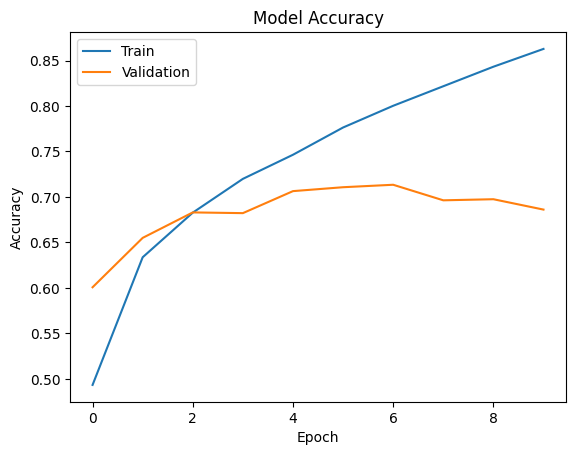

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

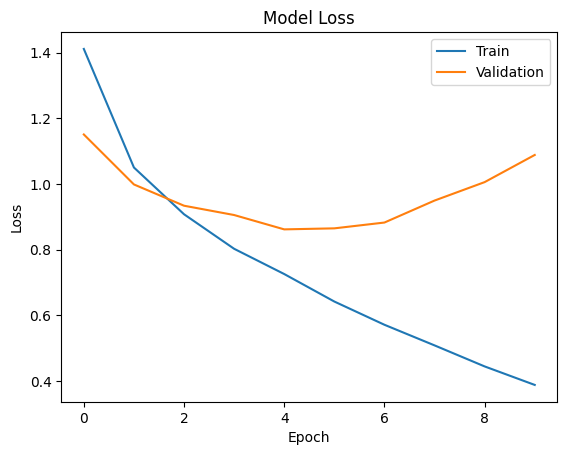

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

# Task 8 – Change Kernel Size from 3×3 to 5×5

In [16]:
model_kernel = Sequential()

model_kernel.add(
    Conv2D(
        filters=32,
        kernel_size=(5,5),
        activation='relu',
        input_shape=(32,32,3)
    )
)

model_kernel.add(MaxPooling2D((2,2)))

model_kernel.add(
    Conv2D(
        filters=64,
        kernel_size=(5,5),
        activation='relu'
    )
)

model_kernel.add(MaxPooling2D((2,2)))

model_kernel.add(Flatten())

model_kernel.add(Dense(128, activation='relu'))

model_kernel.add(Dense(10, activation='softmax'))

model_kernel.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_kernel = model_kernel.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

loss_kernel, acc_kernel = model_kernel.evaluate(X_test,y_test)

print("Task 8 Accuracy:", acc_kernel)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.4709 - loss: 1.4704 - val_accuracy: 0.5790 - val_loss: 1.1962
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6075 - loss: 1.1154 - val_accuracy: 0.6232 - val_loss: 1.0726
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6646 - loss: 0.9608 - val_accuracy: 0.6537 - val_loss: 1.0016
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6987 - loss: 0.8607 - val_accuracy: 0.6782 - val_loss: 0.9297
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.7269 - loss: 0.7833 - val_accuracy: 0.6849 - val_loss: 0.9109
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.7505 - loss: 0.7148 - val_accuracy: 0.6853 - val_loss: 0.9298
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7703 - loss: 0.6558 - val_accuracy: 0.6898 - val_loss: 0.9366
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7893 -

# Task 9 – Increase Filters from 32 to 64

In [17]:
model_filter64 = Sequential()

model_filter64.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32,32,3)
    )
)

model_filter64.add(MaxPooling2D((2,2)))

model_filter64.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

model_filter64.add(MaxPooling2D((2,2)))

model_filter64.add(Flatten())

model_filter64.add(Dense(128, activation='relu'))

model_filter64.add(Dense(10, activation='softmax'))

model_filter64.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_filter64 = model_filter64.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

loss_filter64, acc_filter64 = model_filter64.evaluate(X_test,y_test)

print("Task 9 Accuracy:", acc_filter64)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.4935 - loss: 1.4087 - val_accuracy: 0.5887 - val_loss: 1.1624
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6346 - loss: 1.0464 - val_accuracy: 0.6633 - val_loss: 0.9649
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.6877 - loss: 0.8986 - val_accuracy: 0.6672 - val_loss: 0.9742
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7242 - loss: 0.7869 - val_accuracy: 0.7083 - val_loss: 0.8515
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7569 - loss: 0.6959 - val_accuracy: 0.7034 - val_loss: 0.8812
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.7852 - loss: 0.6177 - val_accuracy: 0.7128 - val_loss: 0.8584
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.8079 - loss: 0.5502 - val_accuracy: 0.6952 - val_loss: 0.9211
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8297 -

# Applied Task 1 – Change Kernel Size to 5×5

Applied Task 1 was already implemented in Task 8.

# Applied Task 2 – Change Number of Filters to 128

In [18]:
model_128 = Sequential()

model_128.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32,32,3)
    )
)

model_128.add(MaxPooling2D((2,2)))

model_128.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu'
    )
)

model_128.add(MaxPooling2D((2,2)))

model_128.add(Flatten())

model_128.add(Dense(128, activation='relu'))

model_128.add(Dense(10, activation='softmax'))

model_128.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_128 = model_128.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

loss_128, acc_128 = model_128.evaluate(X_test,y_test)

print("Applied Task 2 Accuracy:", acc_128)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 45ms/step - accuracy: 0.4922 - loss: 1.4071 - val_accuracy: 0.6069 - val_loss: 1.1034
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6360 - loss: 1.0398 - val_accuracy: 0.6511 - val_loss: 0.9897
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.6877 - loss: 0.9003 - val_accuracy: 0.6712 - val_loss: 0.9474
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.7210 - loss: 0.7985 - val_accuracy: 0.6788 - val_loss: 0.9349
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.7497 - loss: 0.7161 - val_accuracy: 0.6795 - val_loss: 0.9378
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 36ms/step - accuracy: 0.7782 - loss: 0.6368 - val_accuracy: 0.6897 - val_loss: 0.9462
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.7999 - loss: 0.5690 - val_accuracy: 0.7063 - val_loss: 0.9168
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.8238 -

# Applied Task 3 – Add Extra Convolution Layer

In [19]:
model_extra = Sequential()

model_extra.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    )
)

model_extra.add(MaxPooling2D((2,2)))

model_extra.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model_extra.add(MaxPooling2D((2,2)))

model_extra.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model_extra.add(MaxPooling2D((2,2)))

model_extra.add(Flatten())

model_extra.add(Dense(128, activation='relu'))

model_extra.add(Dense(10, activation='softmax'))

model_extra.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_extra = model_extra.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

loss_extra, acc_extra = model_extra.evaluate(X_test,y_test)

print("Applied Task 3 Accuracy:", acc_extra)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.4629 - loss: 1.4707 - val_accuracy: 0.5804 - val_loss: 1.1790
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6160 - loss: 1.0940 - val_accuracy: 0.6421 - val_loss: 1.0324
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6739 - loss: 0.9350 - val_accuracy: 0.6751 - val_loss: 0.9311
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7081 - loss: 0.8368 - val_accuracy: 0.6920 - val_loss: 0.9057
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7377 - loss: 0.7528 - val_accuracy: 0.7195 - val_loss: 0.8216
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.7597 - loss: 0.6868 - val_accuracy: 0.6927 - val_loss: 0.9225
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.7805 - loss: 0.6275 - val_accuracy: 0.7172 - val_loss: 0.8360
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7962 -

# Applied Task 4 – Increase Epochs from 10 to 20

In [20]:
model_20 = Sequential()

model_20.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    )
)

model_20.add(MaxPooling2D((2,2)))

model_20.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model_20.add(MaxPooling2D((2,2)))

model_20.add(Flatten())

model_20.add(Dense(128, activation='relu'))

model_20.add(Dense(10, activation='softmax'))

model_20.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_20 = model_20.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test,y_test)
)

loss_20, acc_20 = model_20.evaluate(X_test,y_test)

print("Applied Task 4 Accuracy:", acc_20)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.5020 - loss: 1.3899 - val_accuracy: 0.5976 - val_loss: 1.1403
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6341 - loss: 1.0499 - val_accuracy: 0.6444 - val_loss: 1.0320
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6830 - loss: 0.9083 - val_accuracy: 0.6828 - val_loss: 0.9156
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7213 - loss: 0.7996 - val_accuracy: 0.6793 - val_loss: 0.9366
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.7508 - loss: 0.7143 - val_accuracy: 0.6999 - val_loss: 0.9002
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7771 - loss: 0.6382 - val_accuracy: 0.6992 - val_loss: 0.9067
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8019 - loss: 0.5695 - val_accuracy: 0.6943 - val_loss: 0.9534
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8230 -

In [21]:
from tensorflow.keras.layers import AveragePooling2D

# Applied Task 5 – Replace MaxPooling with AveragePooling

In [22]:
model_avg = Sequential()

model_avg.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    )
)

model_avg.add(AveragePooling2D((2,2)))

model_avg.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model_avg.add(AveragePooling2D((2,2)))

model_avg.add(Flatten())

model_avg.add(Dense(128, activation='relu'))

model_avg.add(Dense(10, activation='softmax'))

model_avg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_avg = model_avg.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

loss_avg, acc_avg = model_avg.evaluate(X_test,y_test)

print("Applied Task 5 Accuracy:", acc_avg)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.4639 - loss: 1.4907 - val_accuracy: 0.5353 - val_loss: 1.2746
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5862 - loss: 1.1710 - val_accuracy: 0.6100 - val_loss: 1.1176
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6397 - loss: 1.0271 - val_accuracy: 0.6376 - val_loss: 1.0241
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6736 - loss: 0.9310 - val_accuracy: 0.6664 - val_loss: 0.9719
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7011 - loss: 0.8531 - val_accuracy: 0.6742 - val_loss: 0.9353
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7245 - loss: 0.7868 - val_accuracy: 0.6865 - val_loss: 0.9080
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7460 - loss: 0.7258 - val_accuracy: 0.7009 - val_loss: 0.8779
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7631 -

In [23]:
print("Original CNN Accuracy      :", test_acc)
print("Kernel 5x5 Accuracy        :", acc_kernel)
print("64 Filters Accuracy        :", acc_filter64)
print("128 Filters Accuracy       :", acc_128)
print("Extra Layer Accuracy       :", acc_extra)
print("20 Epoch Accuracy          :", acc_20)
print("Average Pooling Accuracy   :", acc_avg)

Original CNN Accuracy      : 0.6861000061035156
Kernel 5x5 Accuracy        : 0.6940000057220459
64 Filters Accuracy        : 0.7139000296592712
128 Filters Accuracy       : 0.6969000101089478
Extra Layer Accuracy       : 0.7226999998092651
20 Epoch Accuracy          : 0.6808000206947327
Average Pooling Accuracy   : 0.6938999891281128
